In [1]:
import numpy as np
import scipy.linalg as spLA
import matplotlib.pyplot as plt

# =====================
# SOFT Method
# =====================
def psi0(x, p0, x0):
    y = (1/np.pi)**(0.25)*np.exp(-1*(1/2)*((x-x0)**2)+1j*p0*x)
    return y

def harmonic(xgrid, mass, omega):
    pot = 0.5*mass*(omega**2)*(xgrid**2)
    return pot

def soft(psi, pot_prop, kin_prop):
    out = pot_prop * psi
    out = kin_prop * np.fft.fft(out)
    out = pot_prop * np.fft.ifft(out)
    return out

# Parameter
N          = 512
xmax       = 6.0
xmin       = -6.0
x0         = 1.0
p0         = 0.0
mass       = 1.0
omega      = 1.0
hbar       = 1.0
dx         = (xmax - xmin) / N
dp         = 2*np.pi / (xmax - xmin)
pv         = np.asarray([p0 + (j - N/2) * dp for j in range(N)])
xv         = np.asarray([(j - N/2) * dx for j in range(N)])
pv_fft     = np.fft.fftfreq(N, d=dx) * 2 * np.pi
psio       = psi0(xv, p0, x0)

# Propagator (pakai 1D bukan matrix agar compatible dengan soft())
Nsteps     = 200
total_time = 20.0
tau        = total_time / Nsteps
V_ho       = harmonic(xv, mass, omega)
V_prop     = np.exp(-1.j/hbar * V_ho * tau/2.)
KE_ho      = pv_fft**2 / (2.*mass)
KE_prop    = np.exp(-1.j/hbar * KE_ho * tau)

# Loop propagasi
psi = psio.copy()
for step in range(Nsteps):
    psi = soft(psi, V_prop, KE_prop)

# Simpan hasil klasik
np.save('psi_classical.npy', psi)
classical_result = np.abs(psi)**2
print("Propagasi selesai!")

# =====================
# QuTiP Method
# =====================
import qutip as qt

N_fock     = 128
a          = qt.destroy(N_fock)
xo         = 1.00
po         = 0.00
psi0_qt    = qt.coherent(N_fock, alpha=(xo + 1.j*po)/np.sqrt(2))
mass       = 1.0
hbar       = 1.0
omga       = 1.0
H_ho       = hbar*omga*(a.dag()*a + 1./2.)
n_steps    = 200
total_time = 10
tlist      = np.linspace(0, total_time, n_steps)

result = qt.mesolve(
    H_ho, psi0_qt, tlist, [], [],
    progress_bar=True,
    options=qt.Options(nsteps=len(tlist))
)

print("QuTiP selesai!")

Propagasi selesai!
10.1%. Run time:   0.00s. Est. time left: 00:00:00:00
20.1%. Run time:   0.00s. Est. time left: 00:00:00:00
30.2%. Run time:   0.01s. Est. time left: 00:00:00:00
40.2%. Run time:   0.02s. Est. time left: 00:00:00:00
50.3%. Run time:   0.02s. Est. time left: 00:00:00:00
60.3%. Run time:   0.03s. Est. time left: 00:00:00:00
70.4%. Run time:   0.04s. Est. time left: 00:00:00:00
80.4%. Run time:   0.05s. Est. time left: 00:00:00:00
90.5%. Run time:   0.05s. Est. time left: 00:00:00:00
100.0%. Run time:   0.06s. Est. time left: 00:00:00:00
Total run time:   0.06s
QuTiP selesai!


/mgpfs/home/shakim/miniconda3/envs/qiskit_env/lib/python3.10/site-packages/qutip/solver/options.py:16: FutureWarning: Dedicated options class are no longer needed, options should be passed as dict to solvers.
  warnings.warn(
/mgpfs/home/shakim/miniconda3/envs/qiskit_env/lib/python3.10/site-packages/qutip/solver/solver_base.py:598: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(
/mgpfs/home/shakim/miniconda3/envs/qiskit_env/lib/python3.10/site-packages/qutip/solver/solver_base.py:501: FutureWarning: "progress_bar" is now included in options:
 Use `options={"progress_bar": False / True / "tqdm" / "enhanced"}`
  warnings.warn(


In [2]:
x_exp  = []
p_exp  = []
tlist  = []

# pv urutan FFT natural (tanpa shift)
pv_fft = np.fft.fftfreq(N, d=dx) * 2 * np.pi

psi = psio.copy()
for step in range(Nsteps):
    t = step * tau
    tlist.append(t)
    
    # ⟨x⟩
    x_exp.append(np.sum(np.conj(psi) * xv * psi).real * dx)
    
    # ⟨p⟩
    psi_k = np.fft.fft(psi) * dx / np.sqrt(2*np.pi)
    p_exp.append(np.sum(np.conj(psi_k) * pv_fft * psi_k).real * dp)
    
    psi = soft(psi, V_prop, KE_prop)


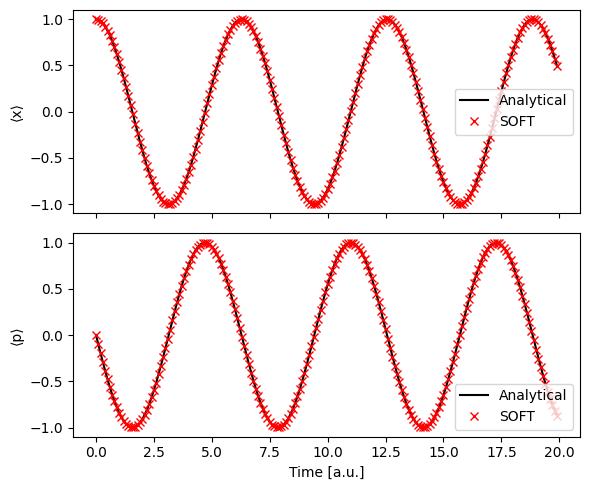

In [3]:
# Analitik
t_arr      = np.array(tlist)
x_analytic = x0 * np.cos(omega * t_arr)
p_analytic = -x0 * omega * np.sin(omega * t_arr)

# Plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 5), sharex=True)

ax1.plot(t_arr, x_analytic, 'k-', label='Analytical')
ax1.plot(t_arr, x_exp,      'rx', label='SOFT')
ax1.set_ylabel('⟨x⟩')
ax1.legend()

ax2.plot(t_arr, p_analytic, 'k-', label='Analytical')
ax2.plot(t_arr, p_exp,      'rx', label='SOFT')
ax2.set_ylabel('⟨p⟩')
ax2.set_xlabel('Time [a.u.]')
ax2.legend()

plt.tight_layout()
plt.show()

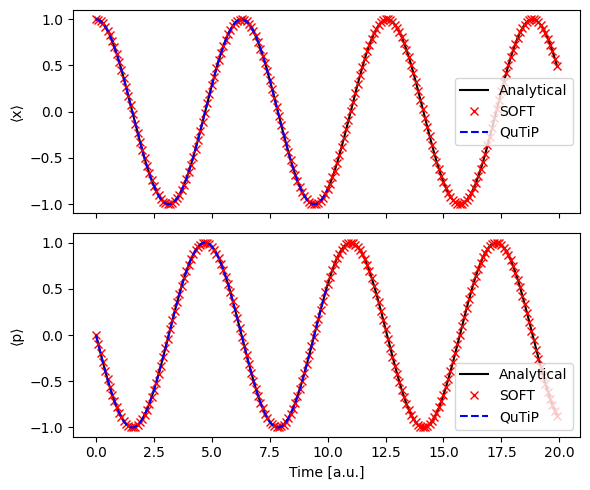

In [4]:
import qutip as qt

# Parameter
N_fock     = 128
a          = qt.destroy(N_fock)
xo         = 1.00
po         = 0.00
psi0_qt    = qt.coherent(N_fock, alpha=(xo + 1.j*po)/np.sqrt(2))
mass       = 1.0
hbar       = 1.0
omga       = 1.0
H_ho       = hbar*omga*(a.dag()*a + 1./2.)

# Operator posisi dan momentum
x_op = (a + a.dag()) / np.sqrt(2)
p_op = 1j*(a.dag() - a) / np.sqrt(2)

# Propagasi dengan ekspektasi value
tlist  = np.linspace(0, total_time, 200)
result = qt.mesolve(H_ho, psi0_qt, tlist, [], [x_op, p_op])

# Ambil hasil ekspektasi
x_qutip = result.expect[0]   # ⟨x⟩
p_qutip = result.expect[1]   # ⟨p⟩

# Plot perbandingan SOFT vs QuTiP vs Analitik
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 5), sharex=True)

ax1.plot(t_arr,  x_analytic, 'k-',  label='Analytical')
ax1.plot(t_arr,  x_exp,      'rx',  label='SOFT')
ax1.plot(tlist,  x_qutip,    'b--', label='QuTiP')
ax1.set_ylabel('⟨x⟩')
ax1.legend()

ax2.plot(t_arr,  p_analytic, 'k-',  label='Analytical')
ax2.plot(t_arr,  p_exp,      'rx',  label='SOFT')
ax2.plot(tlist,  p_qutip,    'b--', label='QuTiP')
ax2.set_ylabel('⟨p⟩')
ax2.set_xlabel('Time [a.u.]')
ax2.legend()

plt.tight_layout()
plt.show()